# **A. Upload Data mah**

In [ ]:
import pandas as pd, numpy as np, re, matplotlib.pyplot as plt
from google.colab import files

pd.set_option("display.max_columns", 100)
print("Ready.")

Ready.


In [ ]:
up = files.upload()
df = pd.read_csv('kesehatan.csv', sep=';')
df.head()

Saving kesehatan.csv to kesehatan.csv


,ID,Nama,Jenis_Kelamin,Usia,Tinggi_cm,Berat_kg,Tekanan_Darah,Diabetes,Cholesterol,Aktifitas_Fisik,Merokok,Riwayat_Penyakit_Keluarga,Diagnosa_Penyakit,Tanggal_Pemeriksaan
0,1,rendy sudiati,Pria,18,187,80,121/74,Ya,normal,sedang,Tidak,Tidak,Sehat,13/08/2024
1,2,"dt. saka hutagalung, s.pd",Laki-laki,42,1540,75,122/78,Tidak,tinggi,sedang,Tidak,Tidak,Sehat,11/11/2024
2,3,Rahayu Saptono,Pria,35,184,99,133/77,Ya,Rendah,Rendah,Ya,Ya,Penyakit Jantung,26/10/2024
3,4,wage kuswoyo,Perempuan,20,186,103,158/67,Tidak,normal,sedang,Tidak,Tidak,Penyakit Jantung,28/03/2025
4,5,jaya sihombing,Laki-laki,23,1420,74,127/65,Tidak,tinggi,NaN,NaN,Tidak,Sehat,10/08/2023


# **B. Cleaning and Feature Engineering uy**

In [ ]:
def to_num(x):
    try: return float(re.sub(r"[^0-9\.\-]", "", str(x)).strip() or np.nan)
    except: return np.nan

def yes_no(x):
    s = str(x).strip().lower()
    if s in ["ya","y","yes","true","1","positif","positive"]: return 1
    if s in ["tidak","no","n","false","0","negatif","negative","-"]: return 0
    return np.nan

def split_bp(x):
    s = str(x)
    m = re.match(r"^\s*(\d{2,3})\D+(\d{2,3})\s*$", s)
    if m: return int(m.group(1)), int(m.group(2))
    try:
        v = int(re.sub(r"[^\d]","", s)); return v, np.nan
    except: return np.nan, np.nan

rename_map = {
    "ID":"id","Nama":"name","Jenis_Kelamin":"gender","Usia":"age",
    "Tinggi_cm":"height_cm","Berat_kg":"weight_kg","Tekanan_Darah":"blood_pressure",
    "Diabetes":"diabetes","Cholesterol":"cholesterol","Aktifitas_Fisik":"activity_level",
    "Merokok":"smoking","Riwayat_Penyakit_Keluarga":"family_history",
    "Diagnosa_Penyakit":"diagnosis","Tanggal_Pemeriksaan":"exam_date",
}
df = df.rename(columns=rename_map)

df["height_cm_num"] = df.get("height_cm").apply(to_num)
df["weight_kg_num"] = df.get("weight_kg").apply(to_num)
df["height_m"]      = df["height_cm_num"]/100.0
df["BMI"]           = df["weight_kg_num"]/(df["height_m"]**2)
df.loc[~np.isfinite(df["BMI"]), "BMI"] = np.nan

if "blood_pressure" in df.columns:
    sbp_dbp = df["blood_pressure"].apply(split_bp)
    df["SBP"] = [t[0] for t in sbp_dbp]
    df["DBP"] = [t[1] for t in sbp_dbp]

df["age_num"]         = df.get("age").apply(to_num)
df["cholesterol_num"] = df.get("cholesterol").apply(to_num)
df["diabetes_bin"]    = df.get("diabetes").apply(yes_no)
df["smoking_bin"]     = df.get("smoking").apply(yes_no)

activity_map = {"rendah":0,"sedang":1,"tinggi":2,"low":0,"medium":1,"med":1,"high":2}
df["activity_ord"] = df.get("activity_level").apply(lambda x: activity_map.get(str(x).strip().lower(), np.nan))

df["family_bin"] = df.get("family_history").apply(yes_no)
df.head()


,id,name,gender,age,height_cm,weight_kg,blood_pressure,diabetes,cholesterol,activity_level,smoking,family_history,diagnosis,exam_date,height_cm_num,weight_kg_num,height_m,BMI,SBP,DBP,age_num,cholesterol_num,diabetes_bin,smoking_bin,activity_ord,family_bin
0,1,rendy sudiati,Pria,18,187,80,121/74,Ya,normal,sedang,Tidak,Tidak,Sehat,13/08/2024,187.0,80.0,1.87,22.877406,121,74,18.0,NaN,1,0.0,1.0,0
1,2,"dt. saka hutagalung, s.pd",Laki-laki,42,1540,75,122/78,Tidak,tinggi,sedang,Tidak,Tidak,Sehat,11/11/2024,1540.0,75.0,15.40,0.316242,122,78,42.0,NaN,0,0.0,1.0,0
2,3,Rahayu Saptono,Pria,35,184,99,133/77,Ya,Rendah,Rendah,Ya,Ya,Penyakit Jantung,26/10/2024,184.0,99.0,1.84,29.241493,133,77,35.0,NaN,1,1.0,0.0,1
3,4,wage kuswoyo,Perempuan,20,186,103,158/67,Tidak,normal,sedang,Tidak,Tidak,Penyakit Jantung,28/03/2025,186.0,103.0,1.86,29.772228,158,67,20.0,NaN,0,0.0,1.0,0
4,5,jaya sihombing,Laki-laki,23,1420,74,127/65,Tidak,tinggi,NaN,NaN,Tidak,Sehat,10/08/2023,1420.0,74.0,14.20,0.366991,127,65,23.0,NaN,0,NaN,NaN,0


# **C. Skor Risiko (Non-Diagnostik) and Label (Low/Medium/High)**

In [ ]:
pts = pd.DataFrame(index=df.index)

pts["age_pts"] = 0.0
pts.loc[df["age_num"] >= 45, "age_pts"] = 1.0
pts.loc[df["age_num"] >= 55, "age_pts"] = 2.0

pts["bmi_pts"] = 0.0
pts.loc[(df["BMI"] >= 25) & (df["BMI"] < 30), "bmi_pts"] = 1.0
pts.loc[df["BMI"] >= 30, "bmi_pts"] = 2.0

pts["bp_pts"] = 0.0
cond1 = ((df["SBP"] >= 130) | (df["DBP"] >= 80))
cond2 = ((df["SBP"] >= 140) | (df["DBP"] >= 90))
pts.loc[cond1, "bp_pts"] = 1.5
pts.loc[cond2, "bp_pts"] = 2.5

pts["dm_pts"]    = np.where(df["diabetes_bin"]==1, 3.0, 0.0)
pts["chol_pts"]  = np.where(df["cholesterol_num"]>=240, 2.0, np.where(df["cholesterol_num"]>=200,1.0,0.0))
pts["smoke_pts"] = np.where(df["smoking_bin"]==1, 2.0, 0.0)
pts["act_pts"]   = np.where(df["activity_ord"]==0, 1.5, np.where(df["activity_ord"]==1,0.5,0.0))
pts["fam_pts"]   = np.where(df["family_bin"]==1, 1.0, 0.0)

pts["raw_total"] = pts.sum(axis=1)
max_total = 2.0 + 2.0 + 2.5 + 3.0 + 2.0 + 2.0 + 1.5 + 1.0
df["risk_score"] = (pts["raw_total"]/max_total).fillna(0).clip(0,1)

q40, q80 = df["risk_score"].quantile([0.4, 0.8])
def band(x):
    if x < q40: return "Low"
    if x < q80: return "Medium"
    return "High"
df["risk_level"] = df["risk_score"].apply(band)

df["risk_level"].value_counts()


,count
risk_level,
Medium,731
Low,448
High,366


# **D. Alasan Utama and Tips Personal (Explainability and Rekomendasi)**

In [ ]:
labels = {
    "dm_pts":"Riwayat Diabetes","bp_pts":"Tekanan darah tinggi","bmi_pts":"BMI berlebih",
    "smoke_pts":"Kebiasaan merokok","chol_pts":"Kolesterol tinggi","act_pts":"Aktivitas fisik rendah",
    "age_pts":"Usia ≥45","fam_pts":"Riwayat keluarga"
}

def reasons(row):
    items = [(labels[k], row[k]) for k in ["dm_pts","bp_pts","bmi_pts","smoke_pts","chol_pts","act_pts","age_pts","fam_pts"] if row.get(k,0)>0]
    items.sort(key=lambda t: t[1], reverse=True)
    return ", ".join([t[0] for t in items[:3]])

def tips(row):
    ts=[]
    if pd.notna(row.get("BMI")) and row["BMI"]>=25: ts.append("Target -5% berat; batasi minuman manis & porsi.")
    if (pd.notna(row.get("SBP")) and row["SBP"]>=130) or (pd.notna(row.get("DBP")) and row["DBP"]>=80):
        ts.append("Kurangi garam; cek tekanan darah ulang 2× minggu ini.")
    if row.get("smoking_bin")==1: ts.append("Mulai rencana 7 hari bebas rokok + dukungan keluarga.")
    if pd.notna(row.get("cholesterol_num")) and row["cholesterol_num"]>=200:
        ts.append("Perbanyak serat & lemak sehat; kurangi gorengan.")
    if row.get("activity_ord",1)<=1: ts.append("Jalan cepat 30 menit, 5×/minggu.")
    if row.get("diabetes_bin")==1: ts.append("Jaga gula darah; ikuti konseling gizi & kontrol rutin.")
    if not ts: ts.append("Pertahankan gaya hidup sehat; lakukan skrining berkala.")
    return " ".join(ts[:3])

df = df.join(pts)
df["top_reasons"] = df.apply(reasons, axis=1)
df["tips"] = df.apply(tips, axis=1)

df.sort_values("risk_score", ascending=False)[["id","name","age_num","BMI","SBP","DBP","cholesterol_num","risk_score","risk_level","top_reasons","tips"]].head(10)


,id,name,age_num,BMI,SBP,DBP,cholesterol_num,risk_score,risk_level,top_reasons,tips
1543,395,Adikara Widodo,77.0,30.457656,161,96,NaN,0.8750,High,"Riwayat Diabetes, Tekanan darah tinggi, BMI be...",Target -5% berat; batasi minuman manis & porsi...
924,925,"drg. wisnu wasita, s.kom",71.0,33.346481,99,96,NaN,0.8750,High,"Riwayat Diabetes, Tekanan darah tinggi, BMI be...",Target -5% berat; batasi minuman manis & porsi...
392,393,"Salsabila Haryanti, M.Ak",66.0,41.380989,113,96,NaN,0.8750,High,"Riwayat Diabetes, Tekanan darah tinggi, BMI be...",Target -5% berat; batasi minuman manis & porsi...
394,395,Adikara Widodo,77.0,30.457656,161,96,NaN,0.8750,High,"Riwayat Diabetes, Tekanan darah tinggi, BMI be...",Target -5% berat; batasi minuman manis & porsi...
567,568,Tomi Widiastuti,69.0,46.990474,119,86,NaN,0.8125,High,"Riwayat Diabetes, BMI berlebih, Kebiasaan merokok",Target -5% berat; batasi minuman manis & porsi...
632,633,Zelda Tarihoran,70.0,32.694532,126,106,NaN,0.8125,High,"Riwayat Diabetes, Tekanan darah tinggi, BMI be...",Target -5% berat; batasi minuman manis & porsi...
390,391,Uchita Farida,73.0,47.665325,130,104,NaN,0.8125,High,"Riwayat Diabetes, Tekanan darah tinggi, BMI be...",Target -5% berat; batasi minuman manis & porsi...
656,657,Hesti Pudjiastuti,64.0,40.057345,133,94,NaN,0.8125,High,"Riwayat Diabetes, Tekanan darah tinggi, BMI be...",Target -5% berat; batasi minuman manis & porsi...
1216,1217,ratih damanik,76.0,26.448980,175,75,NaN,0.8125,High,"Riwayat Diabetes, Tekanan darah tinggi, Kebias...",Target -5% berat; batasi minuman manis & porsi...
1482,1483,Muhammad Handayani,61.0,0.267299,152,79,NaN,0.7500,High,"Riwayat Diabetes, Tekanan darah tinggi, Kebias...",Kurangi garam; cek tekanan darah ulang 2× ming...


# **E. Visual EDA**

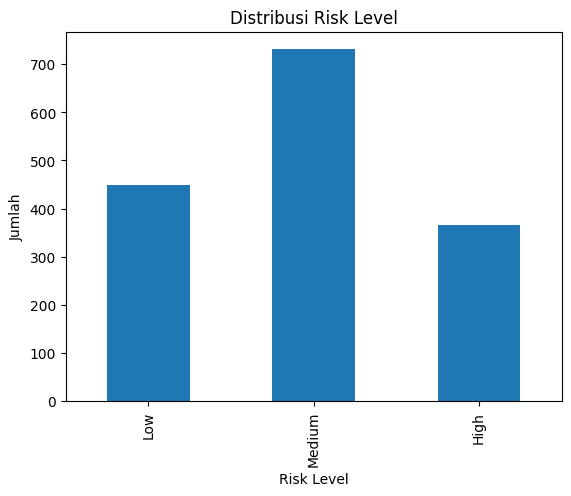

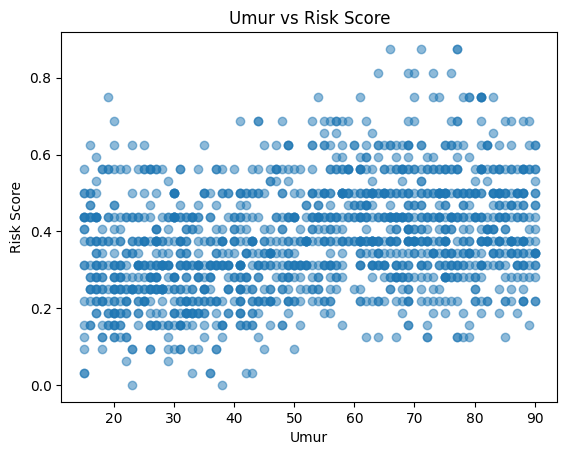

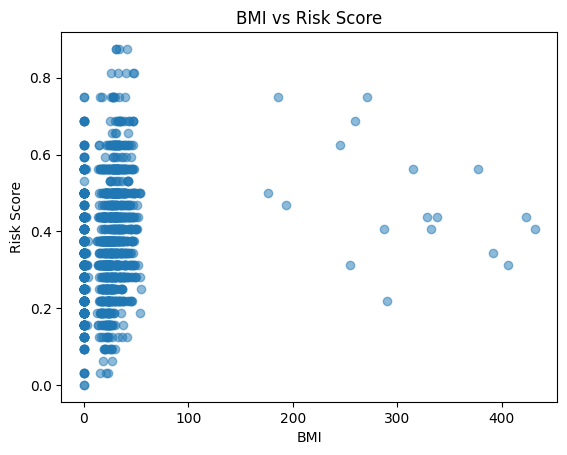

In [ ]:
df["risk_level"].value_counts().reindex(["Low","Medium","High"]).plot(kind="bar")
plt.title("Distribusi Risk Level"); plt.xlabel("Risk Level"); plt.ylabel("Jumlah")
plt.show()

plt.scatter(df["age_num"], df["risk_score"], alpha=0.5)
plt.title("Umur vs Risk Score"); plt.xlabel("Umur"); plt.ylabel("Risk Score")
plt.show()

plt.scatter(df["BMI"], df["risk_score"], alpha=0.5)
plt.title("BMI vs Risk Score"); plt.xlabel("BMI"); plt.ylabel("Risk Score")
plt.show()


# **F. Eksplor Hasil and Top-20% untuk prioritas**

In [ ]:
df.to_csv("kesehatan_risk_scored.csv", index=False)

cut = df["risk_score"].quantile(0.80)
df["priority_flag"] = (df["risk_score"] >= cut).astype(int)

prior = df[df["priority_flag"]==1][["id","name","age_num","BMI","SBP","DBP","cholesterol_num","risk_score","risk_level","top_reasons","tips"]]
prior.to_csv("priority_top20.csv", index=False)
print("Saved: kesehatan_risk_scored.csv & priority_top20.csv")


Saved: kesehatan_risk_scored.csv & priority_top20.csv


## *Fairness and What-If*

In [ ]:
bins = [0,30,45,60,120]
df["age_band"] = pd.cut(df["age_num"], bins=bins, right=False)
fair = (df.groupby(["gender","age_band"])["risk_score"]
          .agg(["count","mean"])
          .rename(columns={"mean":"mean_risk"})
          .reset_index())
fair.head()


/tmp/ipython-input-819608152.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fair = (df.groupby(["gender","age_band"])["risk_score"]


,gender,age_band,count,mean_risk
0,Laki-laki,"[0, 30)",104,0.295373
1,Laki-laki,"[30, 45)",116,0.309806
2,Laki-laki,"[45, 60)",99,0.410038
3,Laki-laki,"[60, 120)",224,0.430943
4,Perempuan,"[0, 30)",156,0.327925


In [ ]:
# What-if: ubah threshold prioritas (mis. 15% atau 25%)
for q in [0.75, 0.85]:
    cut = df["risk_score"].quantile(q)
    n   = (df["risk_score"] >= cut).sum()
    print(f"Ambang quantile {q:.2f} → prioritas {n} orang")


Ambang quantile 0.75 → prioritas 416 orang
Ambang quantile 0.85 → prioritas 366 orang


# **G. Visual**

## *1. Risk Quadrant interaktif (BMI × SBP)*

In [ ]:
!pip -q install plotly kaleido
import plotly.express as px

fig = px.scatter(df, x="BMI", y="SBP",
                 color="risk_level", size="risk_score",
                 hover_data=["name","age_num","cholesterol_num","top_reasons","tips"],
                 title="Risk Quadrant — BMI vs SBP (interaktif)")
fig.write_html("plot_risk_quadrant.html"); fig.show()


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.3/66.3 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.3/52.3 kB 4.8 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/kaleido/_sync_server.py:11: UserWarning:




This means that static image generation (e.g. `fig.write_image()`) will not work.

Please upgrade Plotly to version 6.1.1 or greater, or downgrade Kaleido to version 0.2.1.




In [ ]:
import pandas as pd, numpy as np, plotly.express as px

sun = df[["risk_level","smoking","activity_level"]].copy()

def clean_str(x):
    s = (str(x).strip() if pd.notna(x) else "")
    if s.lower() in ["", "nan", "none", "-", "unknown"]: return "Unknown"
    return s

for c in sun.columns:
    sun[c] = sun[c].map(clean_str)

sun["smoking"] = sun["smoking"].replace({"1":"Yes","0":"No","ya":"Yes","tidak":"No"})

sun["risk_node"]  = "Risk: " + sun["risk_level"].str.title()
sun["smoke_node"] = "Smoke: " + sun["smoking"].str.title()
sun["act_node"]   = "Activity: " + sun["activity_level"].str.title()

agg = (sun.groupby(["risk_node","smoke_node","act_node"])
          .size().reset_index(name="count"))

fig = px.sunburst(
    agg,
    path=["risk_node","smoke_node","act_node"],
    values="count",
    title="Segmentasi Risiko → Kebiasaan Utama"
)
fig.write_html("plot_sunburst.html")
fig.show()


In [ ]:
fig = px.icicle(
    agg,
    path=["risk_node","smoke_node","act_node"],
    values="count",
    title="Icicle: Risiko → Kebiasaan"
)
fig.write_html("plot_icicle.html")
fig.show()


In [ ]:
import plotly.graph_objects as go
high_pct = (df['risk_level']=='High').mean()*100
fig = go.Figure(go.Indicator(mode="gauge+number", value=high_pct,
                             title={'text':'% Populasi High-Risk'},
                             gauge={'axis': {'range':[0,100]}}))
fig.write_html("plot_gauge_high.html"); fig.show()


AUC: 1.0


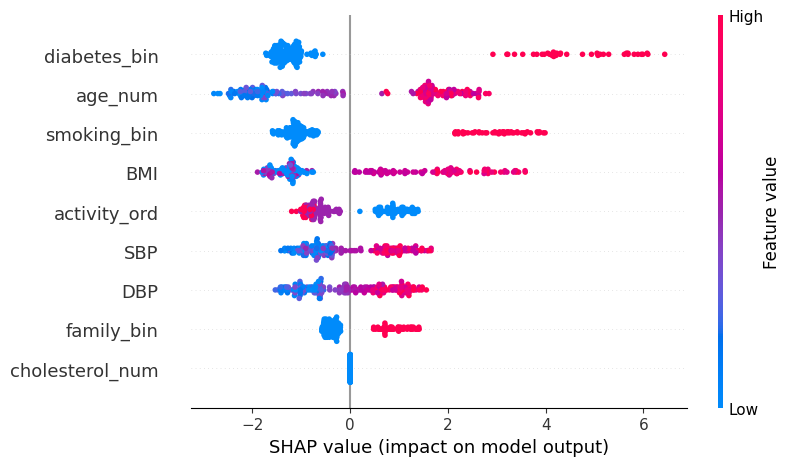

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import roc_auc_score
import shap

use_cols = ["age_num","BMI","SBP","DBP","cholesterol_num","smoking_bin","activity_ord","diabetes_bin","family_bin"]

mask = (df["risk_score"] <= df["risk_score"].quantile(0.40)) | (df["risk_score"] >= df["risk_score"].quantile(0.80))
X = df.loc[mask, use_cols].fillna(-1)
y = (df.loc[mask, "risk_score"] >= df["risk_score"].quantile(0.80)).astype(int)

Xtr, Xte, ytr, yte = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

gb = GradientBoostingClassifier(random_state=42)
gb.fit(Xtr, ytr)

cal = CalibratedClassifierCV(gb, method="isotonic", cv=3)
cal.fit(Xtr, ytr)
proba = cal.predict_proba(Xte)[:, 1]
print("AUC:", roc_auc_score(yte, proba))

shap.initjs()
expl = shap.TreeExplainer(gb)
sv = expl(Xte)
shap.plots.beeswarm(sv, max_display=10, show=True)


In [ ]:
q80_tr = df.loc[Xtr.index, "risk_score"].quantile(0.80)
q40_tr = df.loc[Xtr.index, "risk_score"].quantile(0.40)
ytr = (df.loc[Xtr.index, "risk_score"] >= q80_tr).astype(int)
yte = (df.loc[Xte.index, "risk_score"] >= q80_tr).astype(int)


In [ ]:
for q in [0.70, 0.75, 0.80, 0.85, 0.90]:
    cut = df["risk_score"].quantile(q)
    n = int((df["risk_score"] >= cut).sum())
    print(f"Ambang quantile {q:.2f} → {n} orang prioritas")


Ambang quantile 0.70 → 581 orang prioritas
Ambang quantile 0.75 → 416 orang prioritas
Ambang quantile 0.80 → 366 orang prioritas
Ambang quantile 0.85 → 366 orang prioritas
Ambang quantile 0.90 → 212 orang prioritas


## *Risk Quadrant dengan garis batas klinik umum*

In [ ]:
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go

fig = px.scatter(df, x="BMI", y="SBP",
                 color="risk_level", size="risk_score",
                 hover_data=["name","age_num","cholesterol_num","top_reasons","tips"],
                 title="Risk Quadrant — BMI vs SBP")

for x in [25, 30]:
    fig.add_vline(x=x, line_dash="dash")
for y in [130, 140]:
    fig.add_hline(y=y, line_dash="dash")

fig.update_layout(xaxis_title="BMI", yaxis_title="Sistolik (SBP)")
fig.show()


## *Calibration curve*

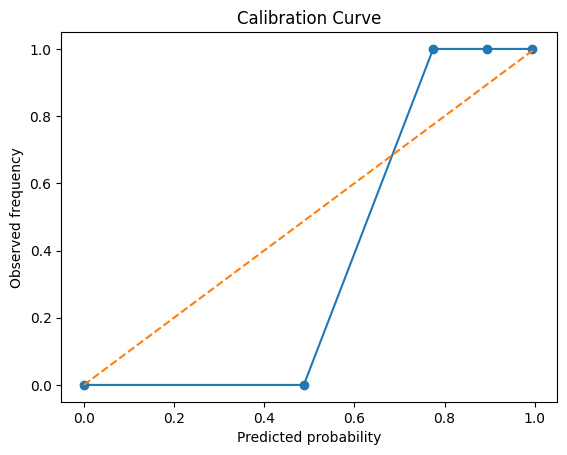

In [ ]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

prob_true, prob_pred = calibration_curve(yte, proba, n_bins=10)
plt.plot(prob_pred, prob_true, marker="o")
plt.plot([0,1],[0,1], "--")
plt.title("Calibration Curve")
plt.xlabel("Predicted probability")
plt.ylabel("Observed frequency")
plt.show()


## *What-If*

In [ ]:
def simulate_bmi_drop(row, drop_pct=0.05):
    bmi_now = row["BMI"]
    if not pd.notna(bmi_now): return np.nan
    bmi_new = bmi_now * (1 - drop_pct)
    # hitung ulang skor dengan aturan yang sama (ringkas)
    age_pts = 2.0 if row["age_num"]>=55 else (1.0 if row["age_num"]>=45 else 0.0)
    bmi_pts = 2.0 if bmi_new>=30 else (1.0 if bmi_new>=25 else 0.0)
    bp_pts  = 2.5 if ((row["SBP"]>=140) or (row["DBP"]>=90)) else (1.5 if ((row["SBP"]>=130) or (row["DBP"]>=80)) else 0.0)
    dm_pts  = 3.0 if row.get("diabetes_bin",0)==1 else 0.0
    chol_pts= 2.0 if row["cholesterol_num"]>=240 else (1.0 if row["cholesterol_num"]>=200 else 0.0)
    smoke_pts=2.0 if row.get("smoking_bin",0)==1 else 0.0
    act_pts = 1.5 if row.get("activity_ord",1)==0 else (0.5 if row.get("activity_ord",1)==1 else 0.0)
    fam_pts = 1.0 if row.get("family_bin",0)==1 else 0.0
    raw = age_pts+bmi_pts+bp_pts+dm_pts+chol_pts+smoke_pts+act_pts+fam_pts
    return raw / (2+2+2.5+3+2+2+1.5+1)

df["risk_score_after_-5pct_weight"] = df.apply(simulate_bmi_drop, axis=1)
df["delta_risk"] = df["risk_score_after_-5pct_weight"] - df["risk_score"]
df[["name","risk_score","risk_score_after_-5pct_weight","delta_risk"]].head()


,name,risk_score,risk_score_after_-5pct_weight,delta_risk
0,rendy sudiati,0.21875,0.21875,0.0
1,"dt. saka hutagalung, s.pd",0.03125,0.03125,0.0
2,Rahayu Saptono,0.62500,0.62500,0.0
3,wage kuswoyo,0.25000,0.25000,0.0
4,jaya sihombing,0.00000,0.00000,0.0


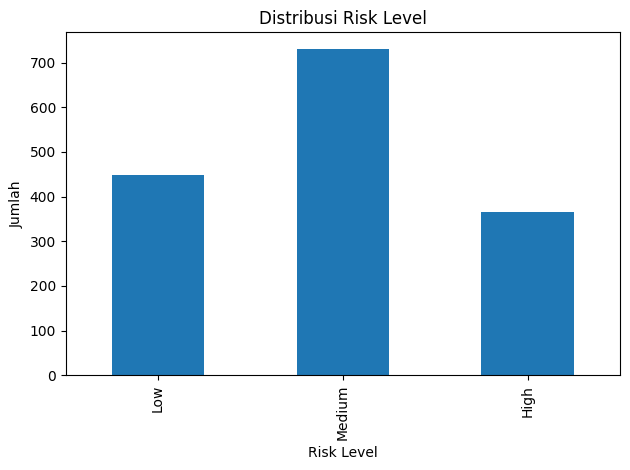

In [ ]:
df["risk_level"].value_counts().reindex(["Low","Medium","High"]).plot(kind="bar")
plt.title("Distribusi Risk Level"); plt.xlabel("Risk Level"); plt.ylabel("Jumlah")
plt.tight_layout(); plt.savefig("chart_risk_level.png"); plt.show()


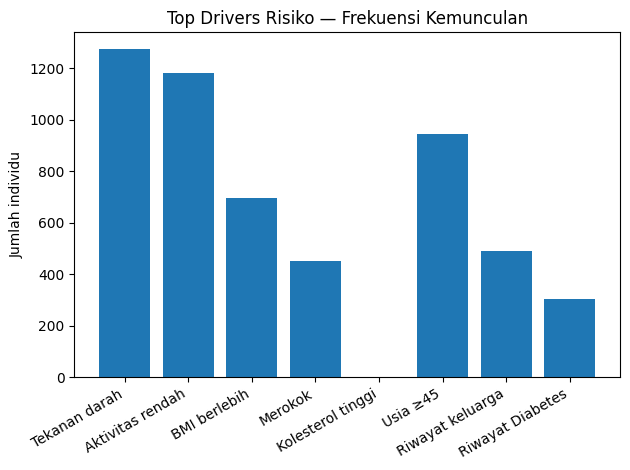

In [ ]:
labels = ["Tekanan darah","Aktivitas rendah","BMI berlebih","Merokok","Kolesterol tinggi","Usia ≥45","Riwayat keluarga","Riwayat Diabetes"]
cols   = ["bp_pts","act_pts","bmi_pts","smoke_pts","chol_pts","age_pts","fam_pts","dm_pts"]
counts = [(pts[c] > 0).sum() for c in cols]
plt.bar(labels, counts); plt.xticks(rotation=30, ha="right")
plt.title("Top Drivers Risiko — Frekuensi Kemunculan"); plt.ylabel("Jumlah individu")
plt.tight_layout(); plt.savefig("top_drivers_bar.png"); plt.show()
